In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd

df = pd.read_csv("PJM_Load_hourly.csv")

df.head()

,Datetime,PJM_Load_MW
0,1998-12-31 01:00:00,29309.0
1,1998-12-31 02:00:00,28236.0
2,1998-12-31 03:00:00,27692.0
3,1998-12-31 04:00:00,27596.0
4,1998-12-31 05:00:00,27888.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32896 entries, 0 to 32895
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datetime     32896 non-null  object 
 1   PJM_Load_MW  32896 non-null  float64
dtypes: float64(1), object(1)
memory usage: 514.1+ KB


In [10]:
df.shape

(32896, 2)

In [11]:
df.describe()

,PJM_Load_MW
count,32896.000000
mean,29766.427408
std,5849.769954
min,17461.000000
25%,25473.000000
50%,29655.000000
75%,33073.250000
max,54030.000000


In [12]:
df.isnull().sum()

,0
Datetime,0
PJM_Load_MW,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df.sort_values('Datetime')

df.head()

,Datetime,PJM_Load_MW
6574,1998-04-01 01:00:00,22259.0
6575,1998-04-01 02:00:00,21244.0
6576,1998-04-01 03:00:00,20651.0
6577,1998-04-01 04:00:00,20421.0
6578,1998-04-01 05:00:00,20713.0


In [15]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Month_Name'] = df['Datetime'].dt.month_name()
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour
df['Weekday'] = df['Datetime'].dt.day_name()

df.head()

,Datetime,PJM_Load_MW,Year,Month,Month_Name,Day,Hour,Weekday
6574,1998-04-01 01:00:00,22259.0,1998,4,April,1,1,Wednesday
6575,1998-04-01 02:00:00,21244.0,1998,4,April,1,2,Wednesday
6576,1998-04-01 03:00:00,20651.0,1998,4,April,1,3,Wednesday
6577,1998-04-01 04:00:00,20421.0,1998,4,April,1,4,Wednesday
6578,1998-04-01 05:00:00,20713.0,1998,4,April,1,5,Wednesday


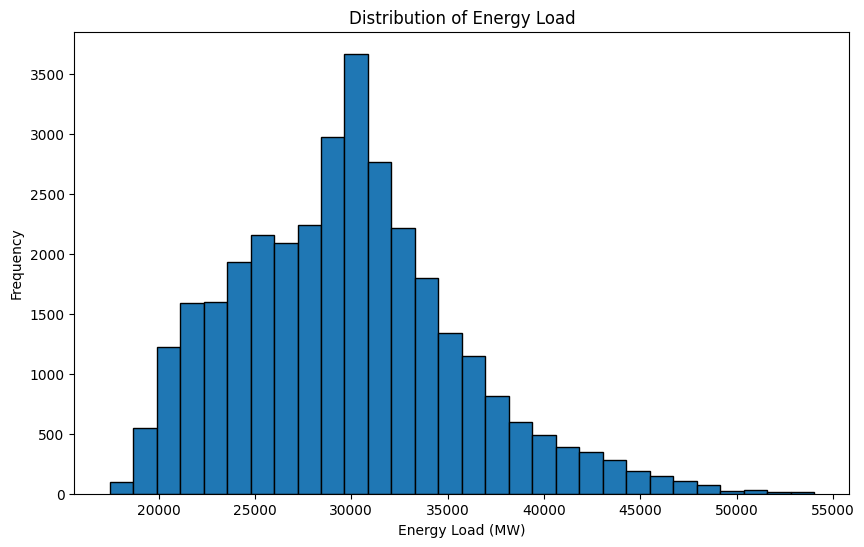

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['PJM_Load_MW'], bins=30, edgecolor='black')
plt.title('Distribution of Energy Load')
plt.xlabel('Energy Load (MW)')
plt.ylabel('Frequency')
plt.show()

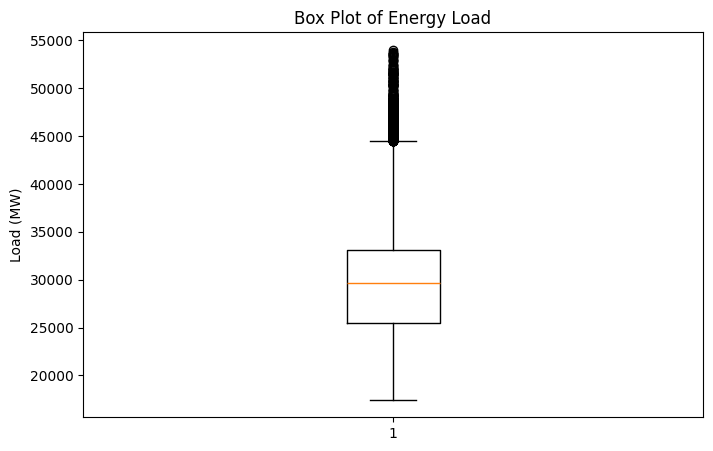

In [17]:
plt.figure(figsize=(8,5))
plt.boxplot(df['PJM_Load_MW'])
plt.title('Box Plot of Energy Load')
plt.ylabel('Load (MW)')
plt.show()

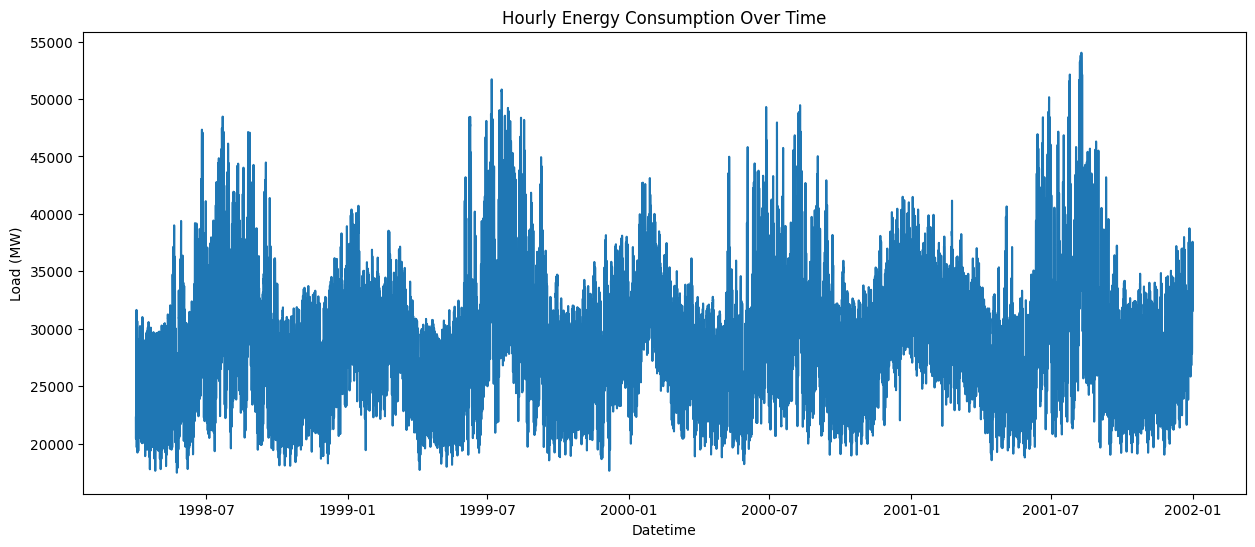

In [18]:
plt.figure(figsize=(15,6))
plt.plot(df['Datetime'], df['PJM_Load_MW'])
plt.title('Hourly Energy Consumption Over Time')
plt.xlabel('Datetime')
plt.ylabel('Load (MW)')
plt.show()

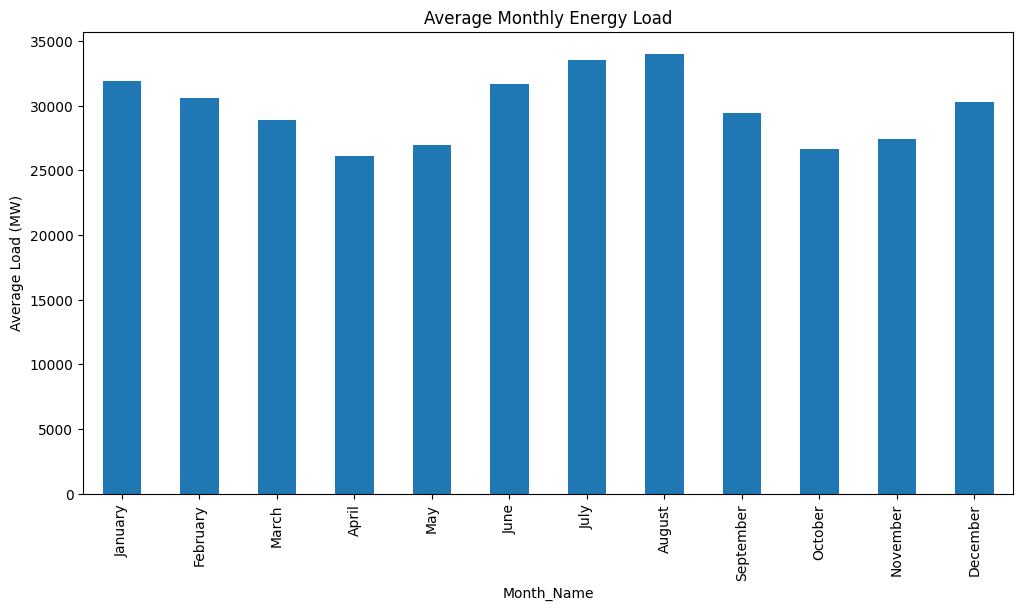

In [19]:
monthly = df.groupby('Month_Name')['PJM_Load_MW'].mean()

monthly = monthly.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(12,6))
monthly.plot(kind='bar')
plt.title('Average Monthly Energy Load')
plt.ylabel('Average Load (MW)')
plt.show()

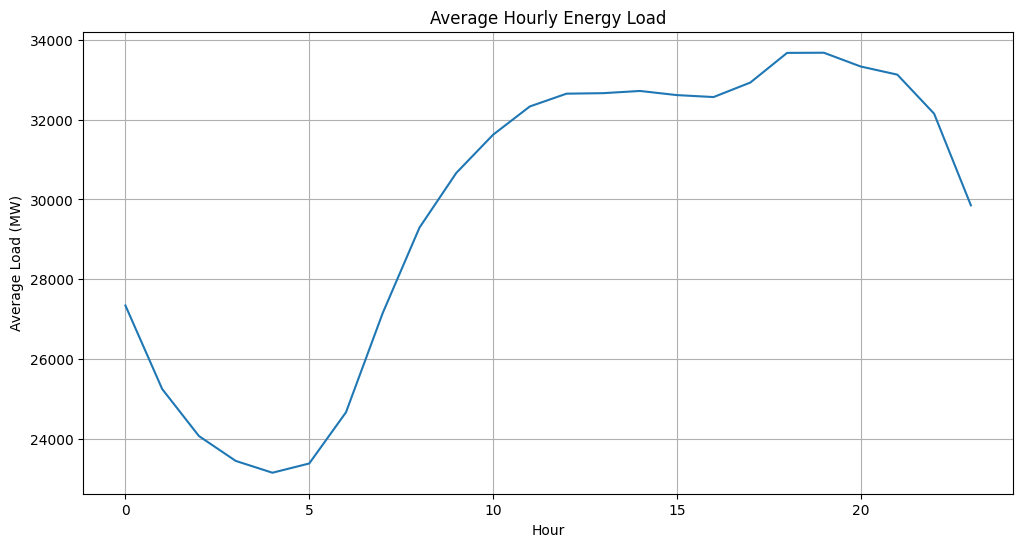

In [20]:
hourly = df.groupby('Hour')['PJM_Load_MW'].mean()

plt.figure(figsize=(12,6))
hourly.plot()
plt.title('Average Hourly Energy Load')
plt.xlabel('Hour')
plt.ylabel('Average Load (MW)')
plt.grid(True)
plt.show()

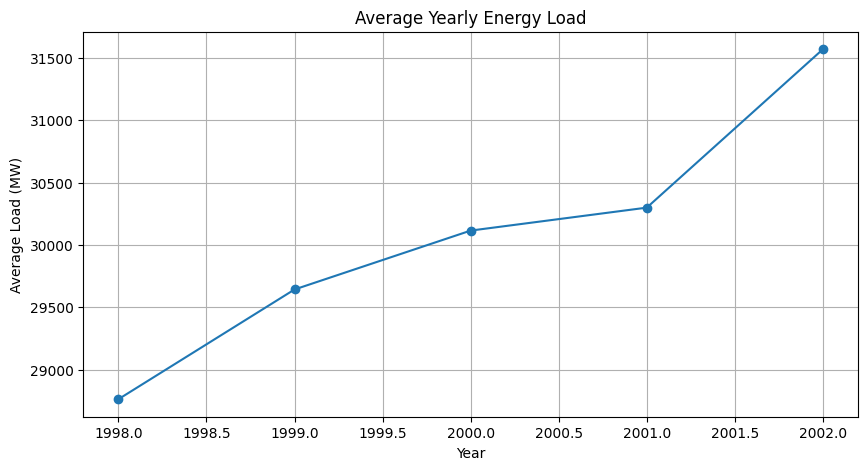

In [21]:
yearly = df.groupby('Year')['PJM_Load_MW'].mean()

plt.figure(figsize=(10,5))
yearly.plot(marker='o')
plt.title('Average Yearly Energy Load')
plt.ylabel('Average Load (MW)')
plt.grid(True)
plt.show()

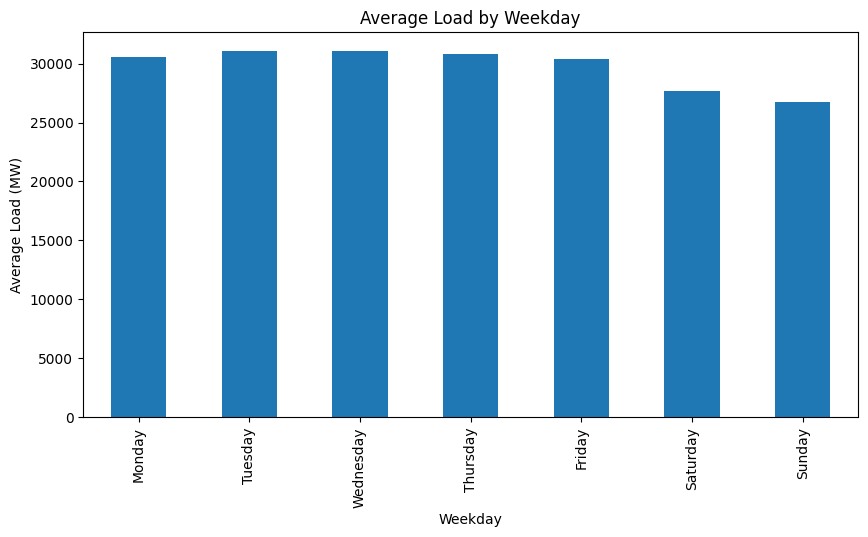

In [22]:
weekday = df.groupby('Weekday')['PJM_Load_MW'].mean()

weekday = weekday.reindex([
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
])

plt.figure(figsize=(10,5))
weekday.plot(kind='bar')
plt.title('Average Load by Weekday')
plt.ylabel('Average Load (MW)')
plt.show()

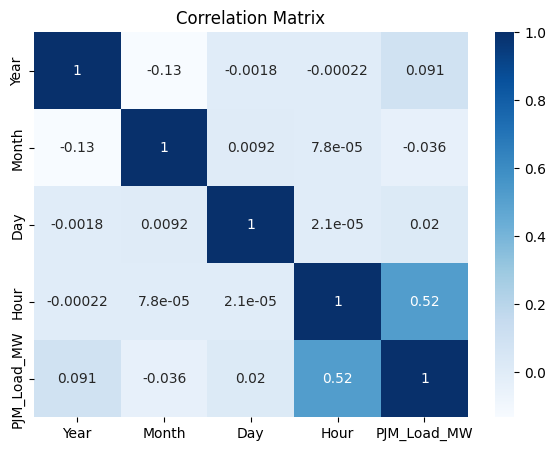

In [23]:
numeric = df[['Year','Month','Day','Hour','PJM_Load_MW']]

corr = numeric.corr()

import seaborn as sns

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

In [24]:
# Features (Input)
X = df[['Year', 'Month', 'Day', 'Hour']]

# Target (Output)
y = df['PJM_Load_MW']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 3839.39059561522
RMSE: 4958.416749402445
R² Score: 0.28944639698081576


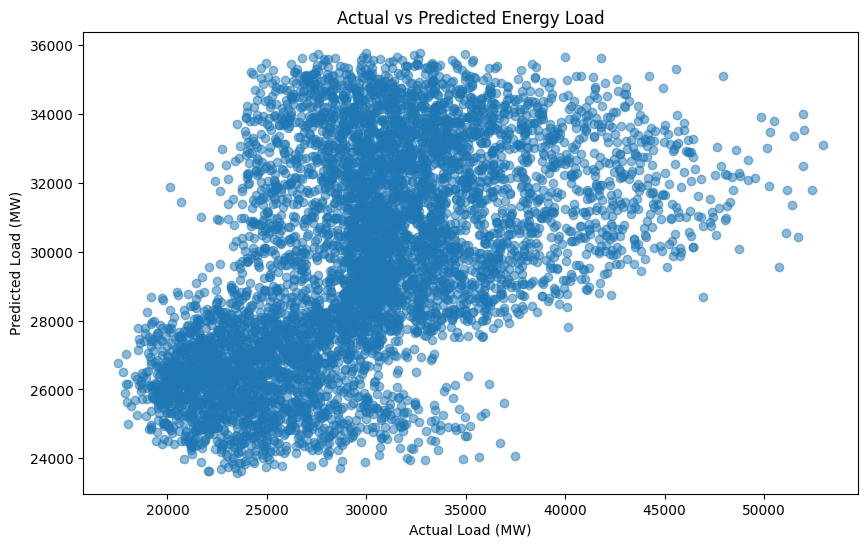

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Load (MW)")
plt.ylabel("Predicted Load (MW)")
plt.title("Actual vs Predicted Energy Load")

plt.show()

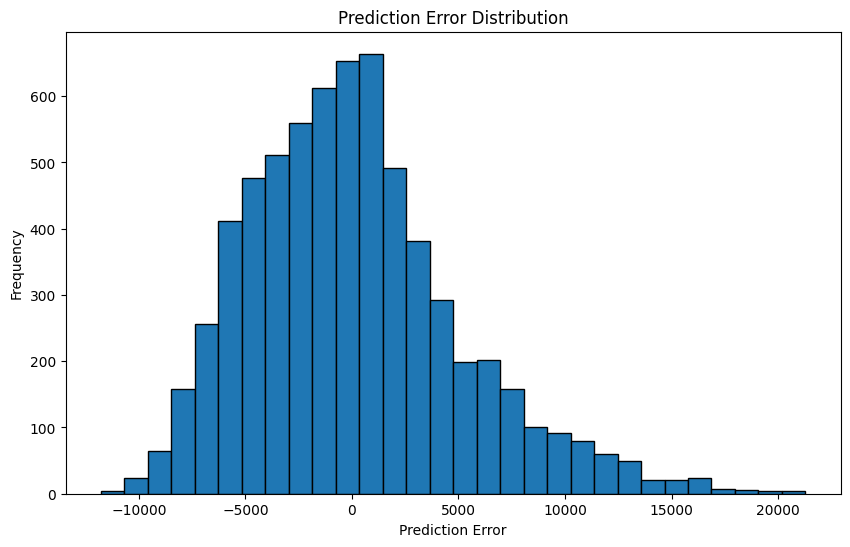

In [31]:
errors = y_test - y_pred

plt.figure(figsize=(10,6))

plt.hist(errors, bins=30, edgecolor='black')

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [33]:
rf_pred = rf.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² Score:", r2_score(y_test, rf_pred))

MAE : 920.4321762917933
RMSE: 1508.1699732809197
R² Score: 0.9342627739264764


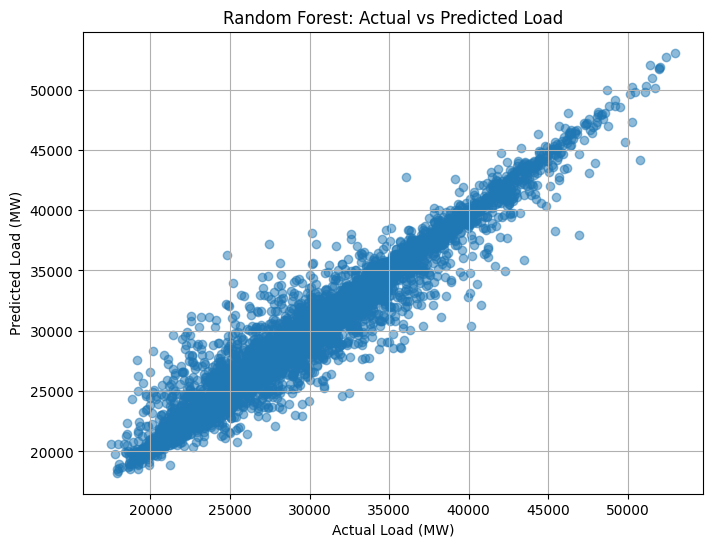

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.xlabel("Actual Load (MW)")
plt.ylabel("Predicted Load (MW)")
plt.title("Random Forest: Actual vs Predicted Load")
plt.grid(True)
plt.show()

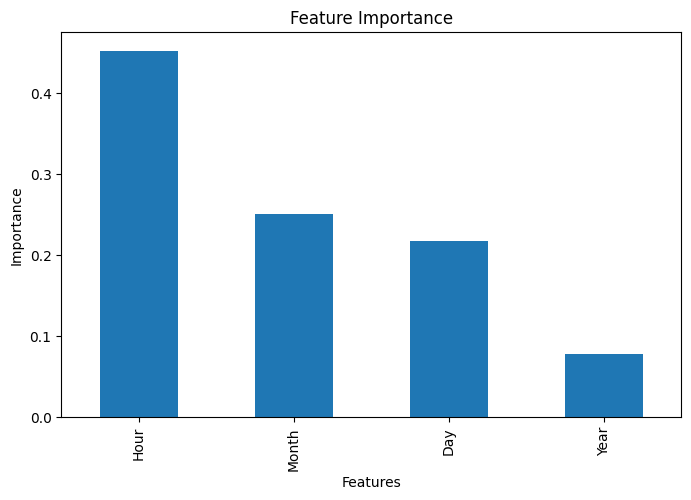

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()